<a href="https://colab.research.google.com/github/lucywowen/csci547_ML/blob/main/examples/SVM_decisiontrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM and Decision Tree hackathon

## The SVM portion of this notebook was adapted from this [article](https://junaidsqazi.medium.com/a44-support-vector-machines-svms-vs-logistic-regression-practice-comparisons-complete-58bbfd72acbe).

In this example, we will be working with three different datasets to compare the performance of SVMs and Logistic regression. The datasets are; MNIST, IRIS and Circles.

Let’s recall logistic regression and compare its performance with support vector machines. We will also explore the available kernel options in SVMs and compare their performance among each other and against simple logistic regression.



In [1]:
# Required imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(font_scale=1.3) # setting font size for the whole notebook
sns.set_style('white') # if you want to set the style
from sklearn import svm, linear_model, datasets
from sklearn.model_selection import cross_val_score
#Retina display to see better quality images.
%config InlineBackend.figure_format = 'retina'
# Lines below are just to ignore warnings
import warnings
warnings.filterwarnings('ignore')

## MNIST
The MNIST (Modified National Institute of Standards and Technology) database of handwritten digits (28x28 pixel grayscale images) consist of 60,000 training and 10,000 test examples. The dataset is a subset of a larger set available from NIST Special Database 3 (digits written by employees of the United States Census Bureau) and Special Database 1 (digits written by high school students) which contain monochrome images of handwritten digits. The digits have been size-normalized and centered in a fixed-size image.

MNIST dataset is a widely used and deeply understood dataset. CNNs (Convolutional Neural Networks) are the top-performing deep learning models that achieve a classification accuracy of above 99%, with an error rate between 0.4% and 0.2% on the hold out test MNIST dataset.

A low resolution (8x8 pixel image) and small subset of MNIST data is included in scikit-learn machine learning library for practice as well.

Let’s load this sample dataset from scikit-learn datasets and see if we can classify the handwritten digits!

In [2]:
mnist = datasets.load_digits()
mnist.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

So, we need data and target keys to grab the data for our classification project — you can explore other fields yourself. If you notice, we have a key 'images' in the list which contains the 8x8 matrices of all the digits.

Let’s get the data in a dataframe df!

In [3]:
df = pd.DataFrame(data=mnist.data, columns=mnist.feature_names)
df['target'] = mnist.target
print(f"We have {len(df)} numbers/observations in the data.")

print(f"Unique target values are: {df.target.unique()}\nand the respective class balance is: {df.target.value_counts().sort_index().values}")
df.tail(2)


We have 1797 numbers/observations in the data.
Unique target values are: [0 1 2 3 4 5 6 7 8 9]
and the respective class balance is: [178 182 177 183 181 182 181 179 174 180]


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9
1796,0.0,0.0,10.0,14.0,8.0,1.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,8.0,12.0,14.0,12.0,1.0,0.0,8


We can see, there are 64 feature, each feature for individual pixel value in 8x8 matrix, right?

Now, if we want to graphically view the image, we can drop the target column from our dataframe df, and grab a row using iloc, then reshape it into 8x8 matrix and use imshow() from matplotlib to visualize the image, super easy!

## Visulaization

Let’s try to visualize some random observation/data-points at some random index, e.g. 1, 5, or -2 to see how the 8x8 image look like in MINIST dataset!



target value is: 9


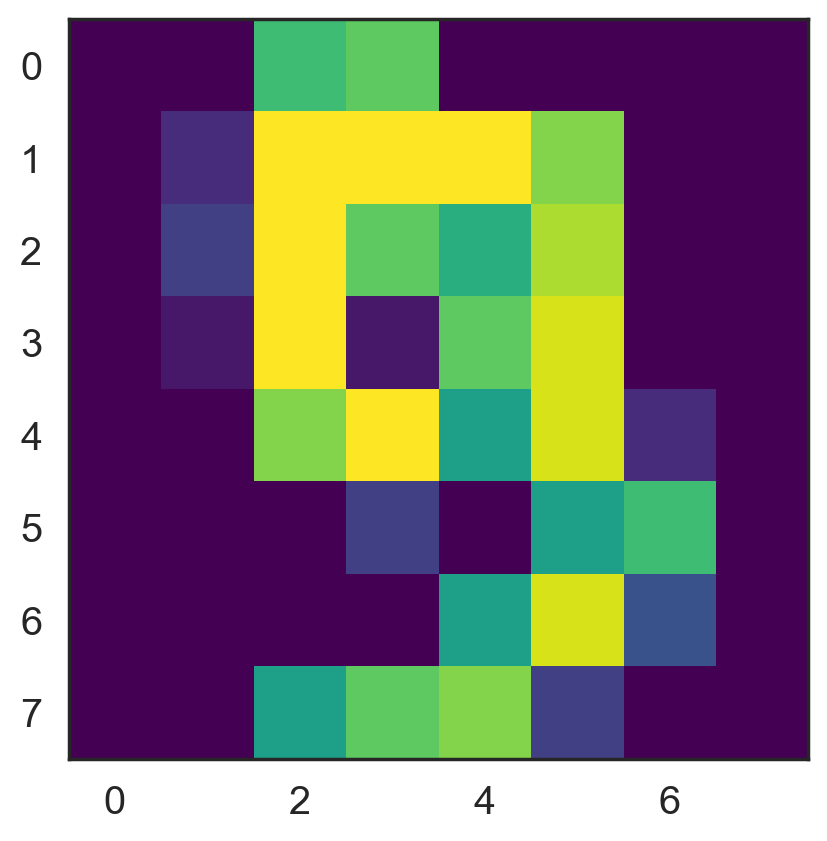

In [6]:
index = 9 #1, 5 or some other available index
number_at_0_index = np.array(
    df.drop(
        'target',
        axis=1
    ).iloc[index]
).reshape(8,8)

print(f"target value is: {int(df.iloc[index][-1])}")
plt.imshow(
    number_at_0_index,
    cmap=plt.cm.viridis
)

## Train the model
Let’s move on, separate features and the target. We can then train logistic regression and SVMs classifier and compare their performance.

In [8]:
digits_X = df.drop('target',axis=1)
digits_y = df.target

#digits_X, digits_y = mnist.data, mnist.target

### Cross-validating logistic regression and SVM on the data
Well, we can start with default setting!



In [17]:
print("Cross-validated mean scores:")

LogR = linear_model.LogisticRegression(multi_class='multinomial')
print(f"\tUsing logistic regession is\t\t: {cross_val_score(estimator=LogR, X=digits_X, y=digits_y,cv=5, scoring='accuracy').mean()}")

# SVM with a linear kernel
svc_linear = svm.SVC(kernel='linear')
svc_linear.fit(digits_X, digits_y)
print(f"\n\tUsing SVC with linear kernel is\t\t: {cross_val_score(estimator=svc_linear, X=digits_X, y=digits_y, cv=5, scoring='accuracy').mean()}")

# SVM with a Gaussian kernel
svc_rbf= svm.SVC(kernel='rbf')
svc_rbf.fit(digits_X, digits_y)
print(f"\tUsing SVC with RBF (Gaussian) kernel is\t: {cross_val_score(estimator=svc_rbf, X=digits_X, y=digits_y, cv=5, scoring='accuracy').mean()}")

Cross-validated mean scores:
	Using logistic regession is		: 0.9137650882079852

	Using SVC with linear kernel is		: 0.9476973073351903
	Using SVC with RBF (Gaussian) kernel is	: 0.9632838130609718


We tried logistic regression with default parameters for comparisons only, however it is not bad. Clearly, SVM gave better performance.

## Hyperparameter tuning and the best model

### $C$

$C$ is the penalty parameter of the error term. It controls the trade off between smooth decision boundary and classifying the training points correctly. $C$ can be thought of as the parameter for the soft margin cost function, which controls the influence of each individual support vector.

- **Small $C$:** makes the decision surface smooth and simple, a softer margin can under-fit! Gives high bias and low variance.
- **Large $C$:** selects more support vectors: can over-fit! Gives a harder margin, low bias and high variance.


### $\gamma$ (Gamma)

Intuitively, the gamma parameter defines how far the influence of a single training example reaches, with low values meaning "far" and high values meaning "close". Gamma is used when we use the Gaussian RBF kernel. If you use linear kernel then you do not need gamma only you need $C$ hypermeter.

The higher the value of gamma, the more it will try to exactly fit the training data set. That will cause over-fitting problems.

- **Small gamma:** The model is constrained and can under-fit! It has high bias and low variance.
- **Large gamma:** The model tries to capture the shape too well: it can over-fit! It has low bias and high variance.


### $\sigma^2$

In class we discussed $\sigma^2$ as the parameter that influenced the Gaussian kernel. $\gamma$ and $\sigma^2$ are inversely related.  

- Gaussian RBF = $\exp\left(- \frac{ \left\Vert x-l^{(1)} \right\Vert^2}{2\sigma^2}\right)$
- $\gamma$ = $\frac{ 1}{2\sigma^2}$
- Gaussian RBF = $\exp\left(- \gamma \left\Vert x-l^{(1)} \right\Vert^2\right)$

You can explore different values of $\sigma^2$ with the code below. Try to change the $\sigma^2$ values to .25, 1, 3, and 10. What happens to the curves?

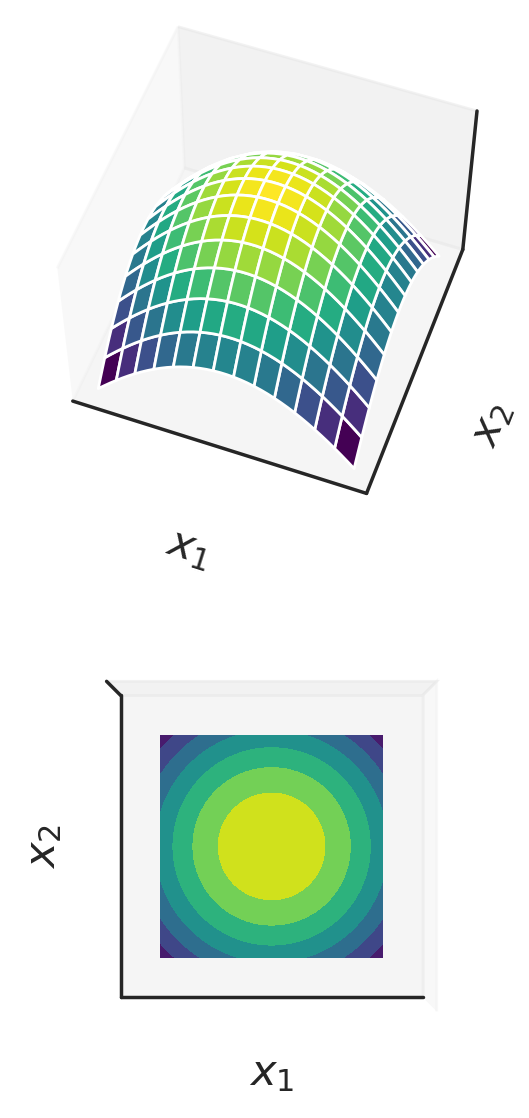

In [22]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Our 2-dimensional distribution will be over variables X and Y
N = 40
X = np.linspace(-2, 2, N)
Y = np.linspace(-2, 2, N)
X, Y = np.meshgrid(X, Y)

# Mean vector and covariance matrix
mu = np.array([0., 0.])
Sigma = np.array([ # You can change the value of sigma here (currently set for 1)
    [10, 0 ],
    [0 , 10]
])

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos: np.ndarray, mu: np.ndarray, Sigma: np.ndarray) -> np.ndarray:
    """
    Return the multivariate Gaussian distribution on array position.
    """
    n = mu.shape[0]
    Sigma_determinant = np.linalg.det(Sigma)
    Sigma_inverse = np.linalg.inv(Sigma)   # inverse matrix of Sigma
    N = np.sqrt((2*np.pi)**n * Sigma_determinant)
    
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inverse, pos-mu)  # tf is this syntax

    return np.exp(-fac / 2) / N

# The distribution on the variables X, Y packed into pos.
Z = multivariate_gaussian(pos, mu, Sigma)

# plot using subplots
fig = plt.figure(figsize=(7,7))

ax1 = fig.add_subplot(2, 1, 1, projection='3d')
ax1.plot_surface(
    X, Y, Z,
    rstride=3,
    cstride=3,
    linewidth=1,
    antialiased=True,
    cmap=cm.viridis
)
ax1.view_init(55,-70)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])
ax1.set_xlabel(r'$x_1$')
ax1.set_ylabel(r'$x_2$')

ax2 = fig.add_subplot(2, 1, 2, projection='3d')
ax2.contourf(
    X, Y, Z,
    zdir='z',
    offset=0,
    cmap=cm.viridis
)
ax2.view_init(90, 270)
ax2.grid(False)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_zticks([])
ax2.set_xlabel(r'$x_1$')
ax2.set_ylabel(r'$x_2$')

plt.show()


Now, if we significantly reduce $\sigma^2$  to a very small value, such as 0.1, we start to count data points as similar within an extremely narrow range. This results in very tight decision boundaries, where each data point essentially only accepts other points in its immediate vicinity. The consequence is “Overfitting” because our model tailors the decision boundaries too precisely to the training data.

So, to sum it up:

- Small $\sigma^2$ or increased gamma = “Overfitting” (too specific decision boundaries)

- Large $\sigma^2$ or decreased gamma = “Underfitting” (too general and inaccurate decision boundaries)

These adjustments help us strike the right balance between model complexity and generalization.




Ok now that we've talked about the hyperparameters, lets explore the space using a gridsearch.  Along with $\gamma$ and $C$, we can look for best kernel in the gridsearch as well. The code below will do this all for you with 5 fold cross-validation (`cv=5`)!

In [26]:
import time
start = time.time()
from sklearn.model_selection import GridSearchCV

# The model
model = svm.SVC()

# Parameters grid
gamma_values = np.logspace(-5, 2, 10)
C_values = np.logspace(-3, 2, 10)
kernels = ['rbf', 'linear']
param_grid = dict(gamma=gamma_values, C=C_values, kernel=kernels)

# Grid search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    # param_grid={  # this is equivalent to the line above
    #     'gamma': gamma_values,
    #     'C': C_values,
    #     'kernel': kernels,
    # },
    cv=5,
    scoring='accuracy',
    verbose=1
)
grid.fit(digits_X, digits_y)

end = time.time()-start
print(f"GridSearch took {end:.2f} sec")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
GridSearch took 69.02 sec


So, the gridsearch took ~168 sec on my machine. Depending upon your computer, expect different time to complete the search.

Well, let’s see what are the best suggested values of the parameters ($C$, $\gamma$ & kernel) from the given ones!

In [28]:
# Check the results of the grid search
print("The best set of parameters is: ", grid.best_params_)
print("The best score is: ", grid.best_score_)
best_svm = grid.best_estimator_

The best set of parameters is:  {'C': np.float64(7.742636826811277), 'gamma': np.float64(0.00035938136638046257), 'kernel': 'rbf'}
The best score is:  0.9732930981120396


In [29]:
grid_results = pd.DataFrame(grid.cv_results_)

# We can separate the values of parameters in
# individual column from params dictionary as well.
grid_results['C'] = [
    x['C'] for x in grid_results.params.values
]
grid_results['gamma'] = [
    x['gamma'] for x in grid_results.params.values
]
grid_results['kernel'] = [
    x['kernel'] for x in grid_results.params.values
]
grid_results['mean_score'] = grid_results['mean_test_score']

# There are several columns, we are just grabing few!
grid_results[['C', 'gamma', 'kernel', 'mean_score']].sort_values('mean_score', ascending=False)\
    .head()

# In total, we have results equivalent to the number of
# candidates in the gridsearch, and we can save all results as .csv file!

,C,gamma,kernel,mean_score
144,7.742637,0.000359,rbf,0.973293
164,27.825594,0.000359,rbf,0.973293
184,100.000000,0.000359,rbf,0.973293
124,2.154435,0.000359,rbf,0.968844
166,27.825594,0.002154,rbf,0.966069


So, the best model is our final model trained on complete dataset (we actually did not split data into train and test sets).

Let's move on and work with IRIS dataset now!

## The IRIS dataset

### Model training and comparisons

We will load the iris data from scikit-learn and scale the features before we cross-validate both logistic regression and SVM classifiers.

In [30]:
# import data
iris = datasets.load_iris()
iris_X = iris.data # data 4
iris_y = iris.target # target

# rescaling features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
iris_X = scaler.fit_transform(iris_X)

# Working with only 2 features, you can try all
X = iris_X[:,:2]

print("Cross-validated mean scores:")
# Testing logistic Regression with default parameters
LogR = linear_model.LogisticRegression()
print("\tUsing Logistic Regression\t:", cross_val_score(LogR, X, iris_y, cv=5, scoring='accuracy').mean())

# Testing SVM with default parameters
model = svm.SVC()
print("\tUsing SVMs\t\t\t:", cross_val_score(model, X, iris_y, cv=5, scoring='accuracy').mean())


Cross-validated mean scores:
	Using Logistic Regression	: 0.8133333333333332
	Using SVMs			: 0.8066666666666666


In the above code, we used default parameters for both classifiers. We have kernel options in SVM, let’s see how the two kernels (Gaussian/rbf and linear) work with the data using SVM.

In [31]:
# What about SVM with default parameters and different kernels using
# the same scaled data?

# The models
C=1.0
print("Scores from the selected models:")
linear_svc = svm.SVC(kernel='linear', C=C)\
    .fit(X, iris_y)
rbf_svc = svm. SVC (kernel='rbf', gamma=0.7, C=C)\
    .fit(X, iris_y)

# Scores
print("\tSVM with linear kernel\t\t:", linear_svc.score(X, iris_y))
print("\tSVM with RBF kernel\t\t:",rbf_svc.score(X, iris_y))


Scores from the selected models:
	SVM with linear kernel		: 0.8133333333333334
	SVM with RBF kernel		: 0.82


RBF kernel is actually giving us better score. Well, it might be good idea to see the decision boundaries that are set by the two models with their respective kernels!

### SVM visualizing kernel effects

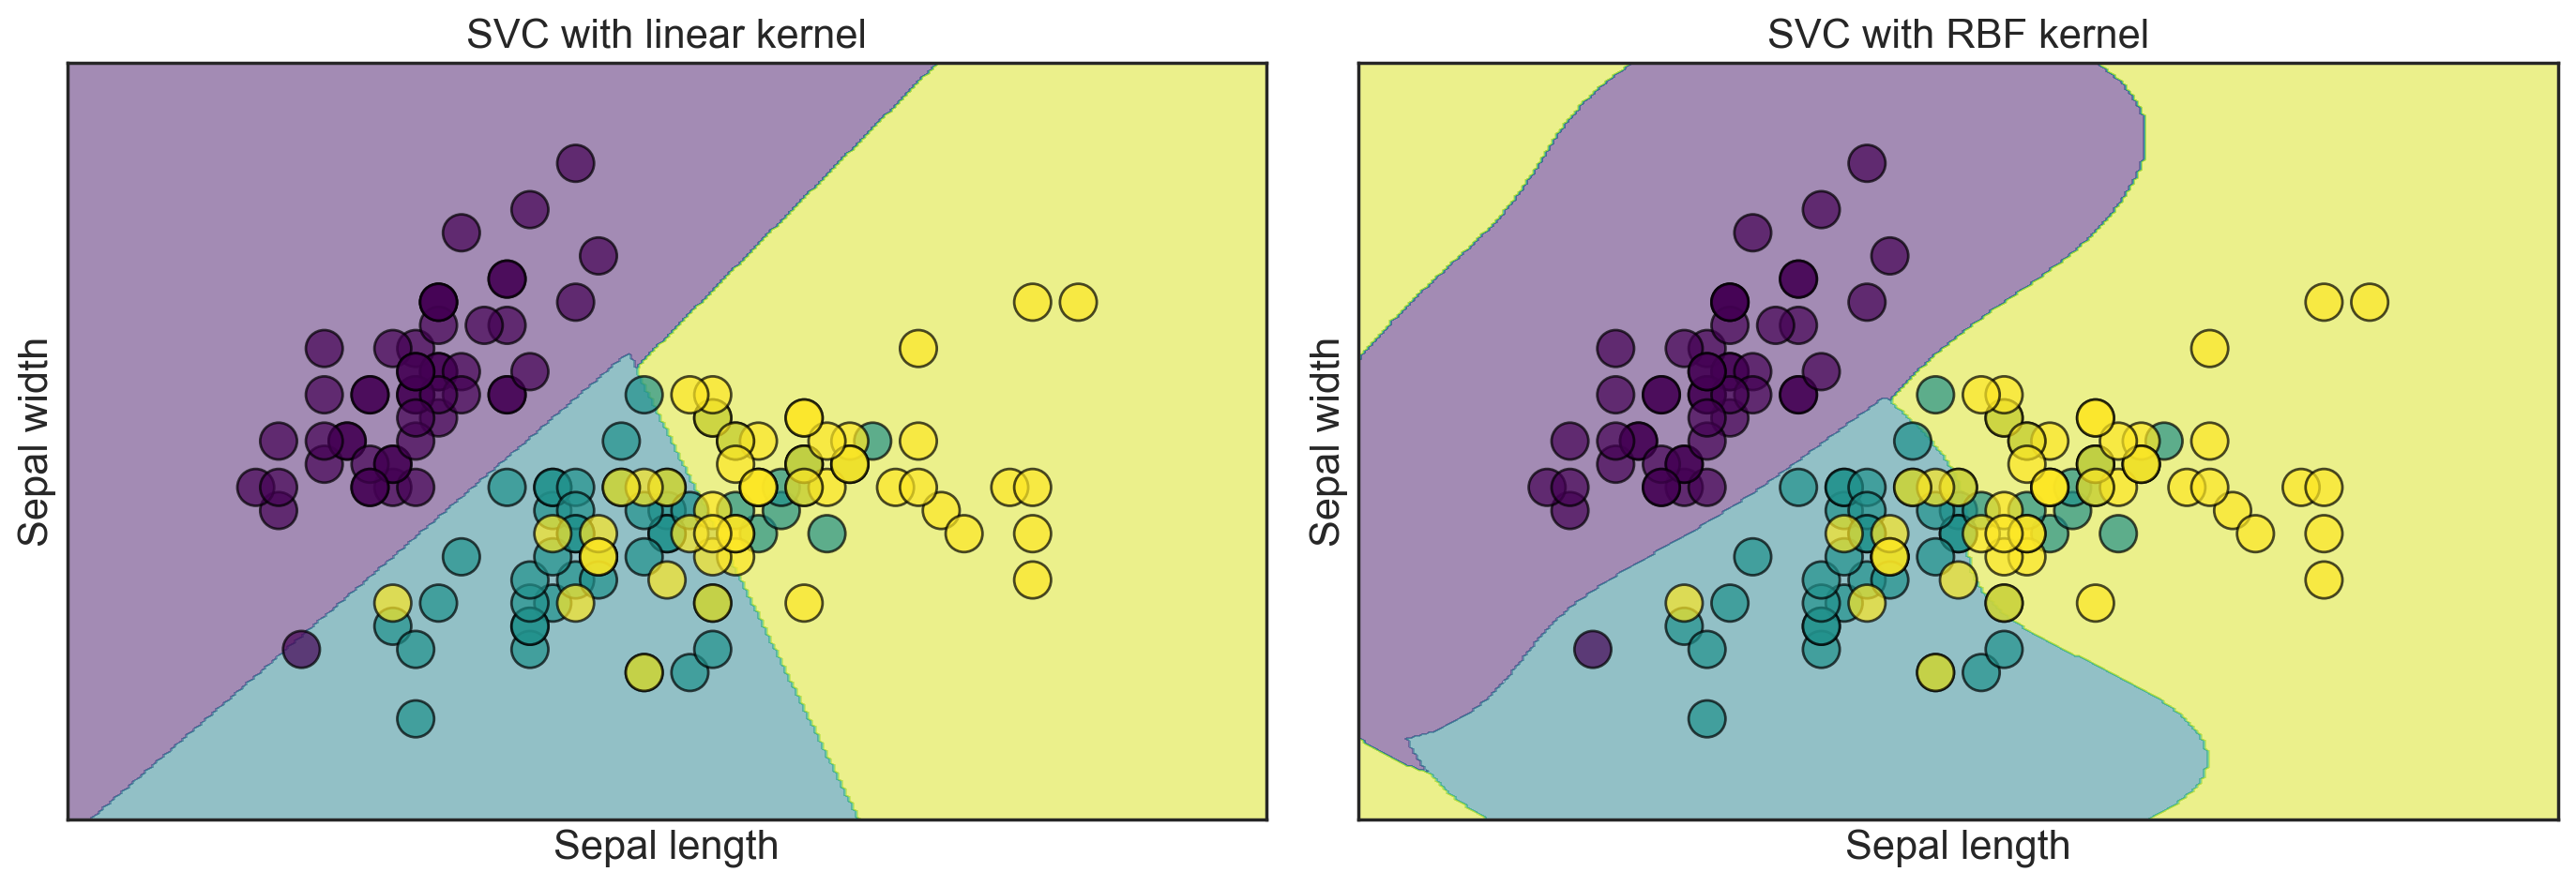

In [33]:
# Creating a mesh for the plots
x_min, x_max = iris_X[:, 0].min() - 1,  iris_X[:, 0].max() + 1
y_min, y_max = iris_X[:, 1].min() - 1,  iris_X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, .02),
    np.arange(y_min, y_max, .02),
)

# title for the plots
titles = ['SVC with linear kernel', 'SVC with RBF kernel']

plt.figure(figsize=(14,5))

for i, model in enumerate((linear_svc, rbf_svc)):
    plt.subplot(1, 2, i+1)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.5)
    
    # Plot also the training points
    plt.scatter(
        iris_X[:, 0], iris_X[:, 1],
        c=iris_y,
        cmap=plt.cm.viridis,
        s=200,
        edgecolors='black',
        alpha=0.7
    )
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xticks([])
    plt.yticks([])
    plt.title(titles[i])

plt.tight_layout()

Moving forward, let’s explore the real power of Support Vector Machines, which is its capability of classifying non-linearly separable data!

## The circles data — non-linearly separable data
Let’s create a data with circle within a circle using sklearn’s make_circles and compare cross-validated scores for logistic regression and different SVM kernels. The code below will do this all for you!

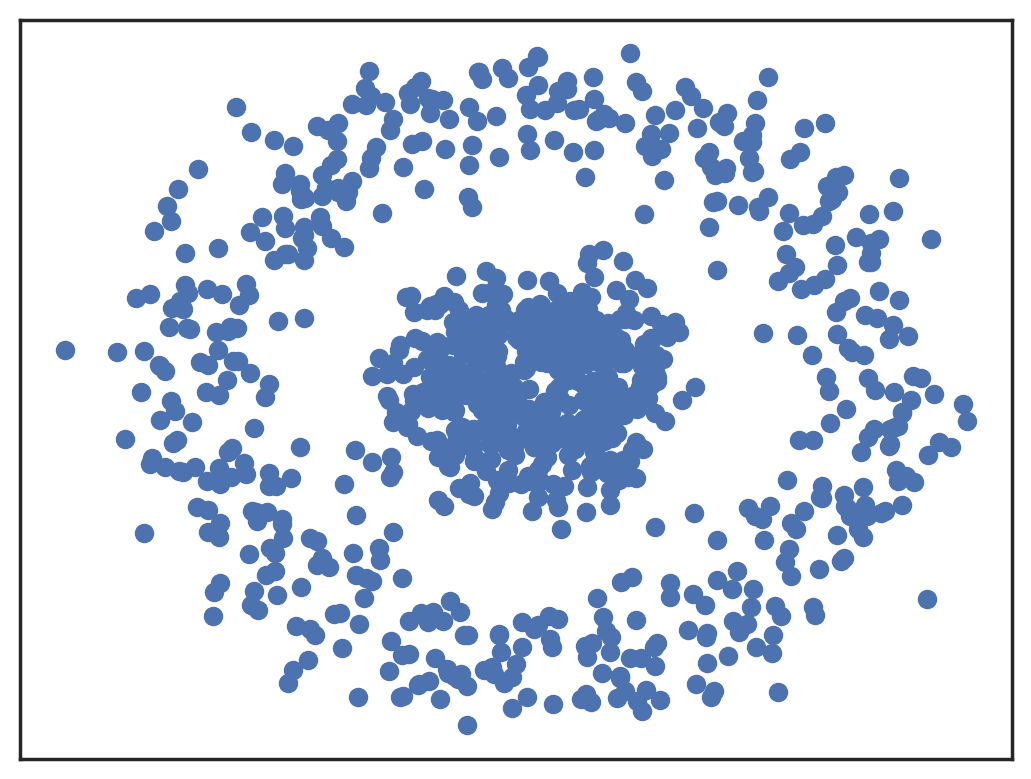

In [17]:
from sklearn.datasets import make_circles
# Making circles
circles_X, circles_y = make_circles (n_samples=1000, random_state=123, noise=0.14, factor=0.2)

# Scaling
circles_X = StandardScaler().fit_transform(circles_X)

# Plotting the data in case you want to visualize the data
plt.scatter(circles_X[:,0], circles_X[:,1])
plt.xticks(()); plt.yticks(());


In [18]:
# cross-validated mean scors:
print("Cross-validated mean scores:")
print("\tLogistic regression\t\t: ",cross_val_score(linear_model.LogisticRegression(), circles_X, circles_y, cv=5, scoring='accuracy').mean())
print("\tSVM Linear kernel\t\t: ", cross_val_score(svm.SVC(kernel = 'linear'), circles_X,circles_y, cv=5, scoring='accuracy').mean())
print("\tSVM RBF kernel\t\t\t: ",cross_val_score(svm.SVC(kernel = 'rbf'), circles_X,circles_y, cv=5, scoring='accuracy').mean())

Cross-validated mean scores:
	Logistic regression		:  0.49400000000000005
	SVM Linear kernel		:  0.635
	SVM RBF kernel			:  1.0


From the above scores, clearly, logistic regression is not the option for non-linearly separable data. However, we see rbf kernel is doing the magic for SVM and clearly separating classes with 100% accuracy. Well, we may want to visualize what is happening using different kernels in SVM and how they are actually working for this complex data.

### Visualizing kernel effects for circles data

We have used two kernels, linear and rbf in the above code for SVM. Let’s plot the decision boundaries and see how they are classifying the complex dataset. Give sometime and understand the code below, it should be pretty simple at this stage of the course!

SVM scores are:
	with linear kernel	: 0.669
	with RBF kernel		: 1.0


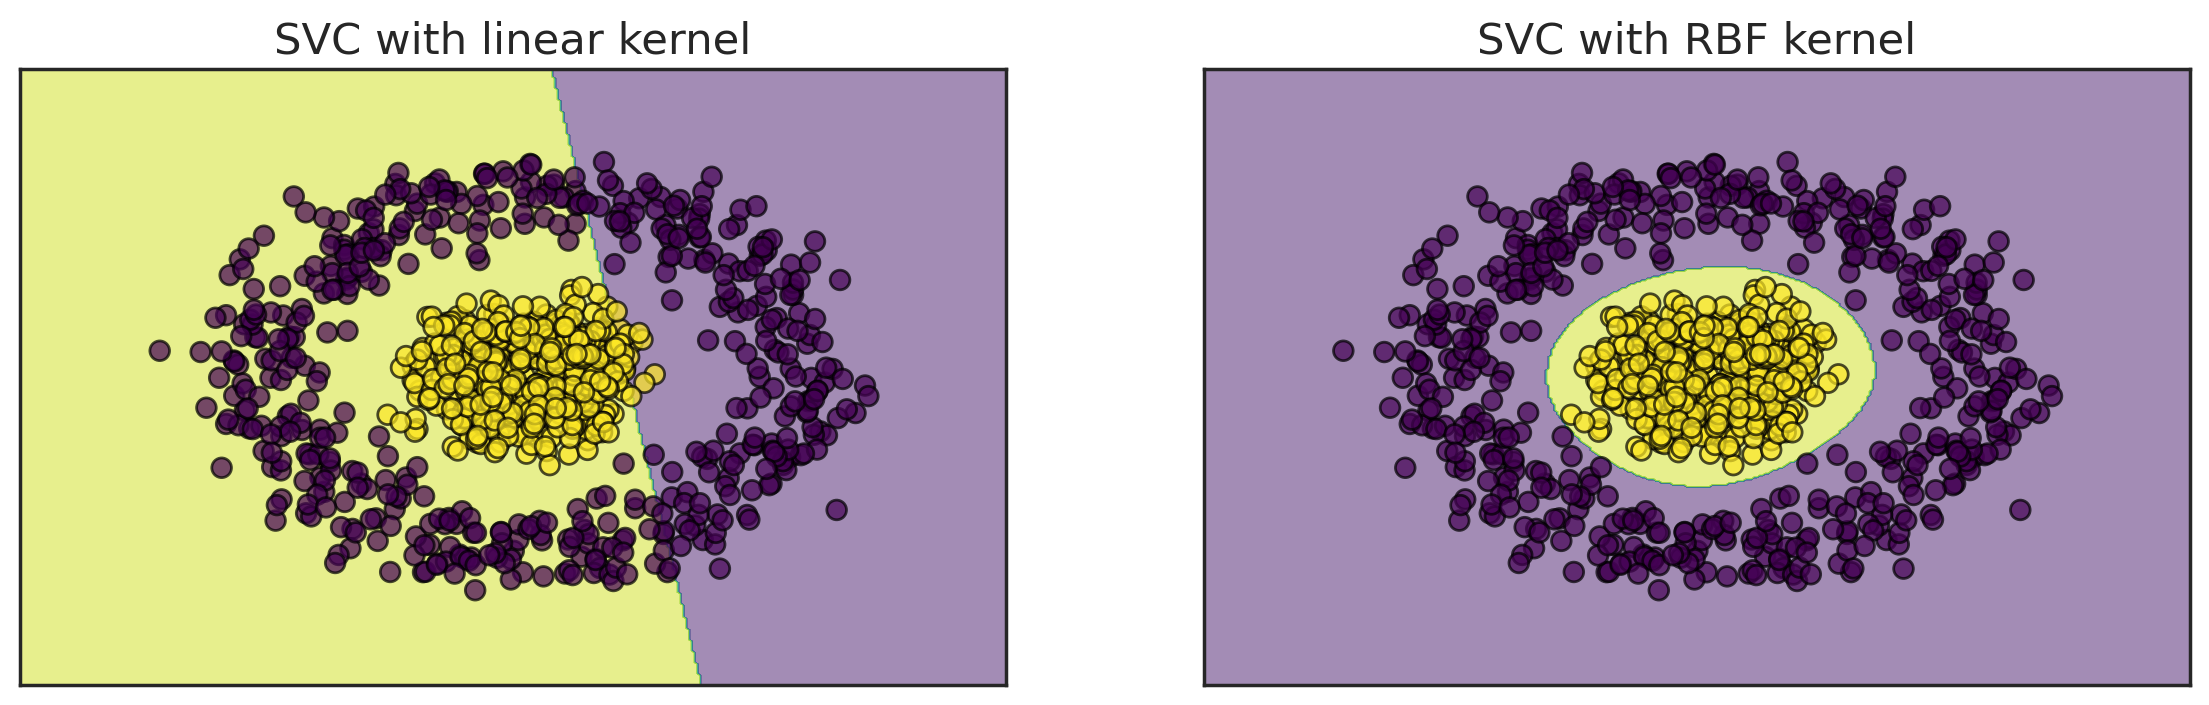

In [19]:
C = 1.0 # This is alos the default value in SVM regularization parameter
linear_svc = svm.SVC(kernel='linear', C=C).fit(circles_X, circles_y)
rbf_svc = svm.SVC(kernel='rbf', gamma=0.7, C=C).fit(circles_X, circles_y) # default

print("SVM scores are:")
print("\twith linear kernel\t:", linear_svc.score(circles_X, circles_y))
print("\twith RBF kernel\t\t:",rbf_svc.score(circles_X, circles_y))

# Creating a mesh for the plots
x_min, x_max = circles_X[:, 0].min() - 1, circles_X[:, 0].max() + 1
y_min, y_max = circles_X[:, 1].min() - 1, circles_X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, .02), np.arange(y_min, y_max, .02))

# title for the plots
titles= ['SVC with linear kernel','SVC with RBF kernel']

plt.figure(figsize=(14,4))
for i, clf in enumerate((linear_svc, rbf_svc)):
  plt.subplot(1, 2, i+1)
  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  # Adding result on a color plot
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.5)
  # Putting the training data
  plt.scatter(circles_X[:, 0], circles_X[:, 1], c=circles_y, s=50, edgecolors='black',cmap=plt.cm.viridis, alpha=0.7)
  plt.xticks(()); plt.yticks(()); plt.title(titles[i])

plt.show()



Ok so before moving on, I'm hoping you can answer these three things:

1. How does the regularization hyperparameter (C) play a role in underfitting and overfitting in SVMs?  How is C related to the logistic regression hyperparameter $\lambda$ ?

2. How do the kernel hyperparameters (C, $\sigma^2$, $\gamma$) play a role in underfitting and overfitting in SVMs?

3. How does your choice in kernel (rbf vs linear) change based on the data?

# Decision Trees!

Ok the last thing I want us to do is to visualize some decision trees. This part of the notebook has been adapted from this [article](https://medium.com/@mer423/decision-tree-visualization-e82dc6d5bf9c).  

Decision Trees are a commonly used non-parametric supervised modeling technique that can be applied for both classification and regression purposes. The goal of a decision tree is to create a model that predicts the value of a target variable by learning simple decision rules learned from the data features.

Data scientists use decision trees because they can be used to visually and explicitly represent decisions and decision making. The decision tree algorithm is widely used because of its robustness to noise, tolerance against missing information, low computational cost, interpretability, fast run time, and robust predictors.

The decision tree algorithm can be thought of as a tree turned upside down since the root is at the top. When working with data, at each layer of the tree there is a differentiator that splits the samples into two or more homogenous sets. Depending on the hyperparameters and settings of the decision tree, the tree continues to split until it reaches the final layer, referred to as the leaf.

## Dataset

In order to understand a decision tree and visualize the model, we will again use the Iris flower dataset. The dataset contains information on 50 samples from each of 3 different species of irises (pictured below). Using the four attributes included — sepal length, sepal width, petal length, and petal width — data scientists can predict the species.


First, we should load the data into the memory. Then we can look at the features and take a peek at some of the samples of each class of iris. Personally, I like the structure of a pandas DataFrame, so I’ll share how to see the data in that form. To get all the data in one DataFrame, we have to concatenate the features with the target, which is the number that represents each species (0 = Setosa, 1 = Versicolor, 2 = Virginica).  We've already done this, but lets just do it again:

In [20]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
iris = load_iris()
df= pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                 columns= iris['feature_names'] + ['target'])
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
139,6.9,3.1,5.4,2.1,2.0
21,5.1,3.7,1.5,0.4,0.0
53,5.5,2.3,4.0,1.3,1.0
82,5.8,2.7,3.9,1.2,1.0
130,7.4,2.8,6.1,1.9,2.0


## Split the data
Before we can train the model to generate predictions about the species of iris based on the measurements of the sepal and petal, we need to section off part of the data called the test data that will not be used to train the model. To do this, we use scikit-learn’s train_test_split function from the model_selection module.

In [21]:
from sklearn.model_selection import train_test_split
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state = 42,
                                                    test_size = 0.2)

## Training the Decision Tree
In order to build the decision tree, we will use the scikit-learn Decision Tree Classifier from the tree module.

In [22]:
from sklearn.tree import DecisionTreeClassifier
# instantiate the classifier
dtc = DecisionTreeClassifier(criterion='entropy', random_state=42)
#fit the model
dtc.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

That’s it! Isn’t that crazy that it takes so little code to build a whole decision tree?? Now keep in mind, when building a decision tree, we often prune the model using hyperparameter tuning. When left unpruned, a decision tree is likely to be overfit. Take a look at this helpful [guide](https://towardsdatascience.com/how-to-tune-a-decision-tree-f03721801680) that goes through hyperparameter tuning decisions that can be made with a decision tree. For the purposes of this example, we will move forward with the decision tree with default hyperparameters.

## Evaluating the model
Now, we run the test data through the model and determine the predictions.

In [23]:
y_pred = dtc.predict(X_test)

Then we can evaluate the model using a number of different metrics.



In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



From this classification report, we can see that the accuracy score is 1.00 meaning the model got 100% of the predictions correct.

## Visualizing the decision tree
In order to help make sense of the model and its results, it can be extremely helpful to view the decision tree. There are numerous ways to make the decision tree visible. One method I have used in the past is plot_tree which uses Matplotlib to plot the decision tree on an axis.

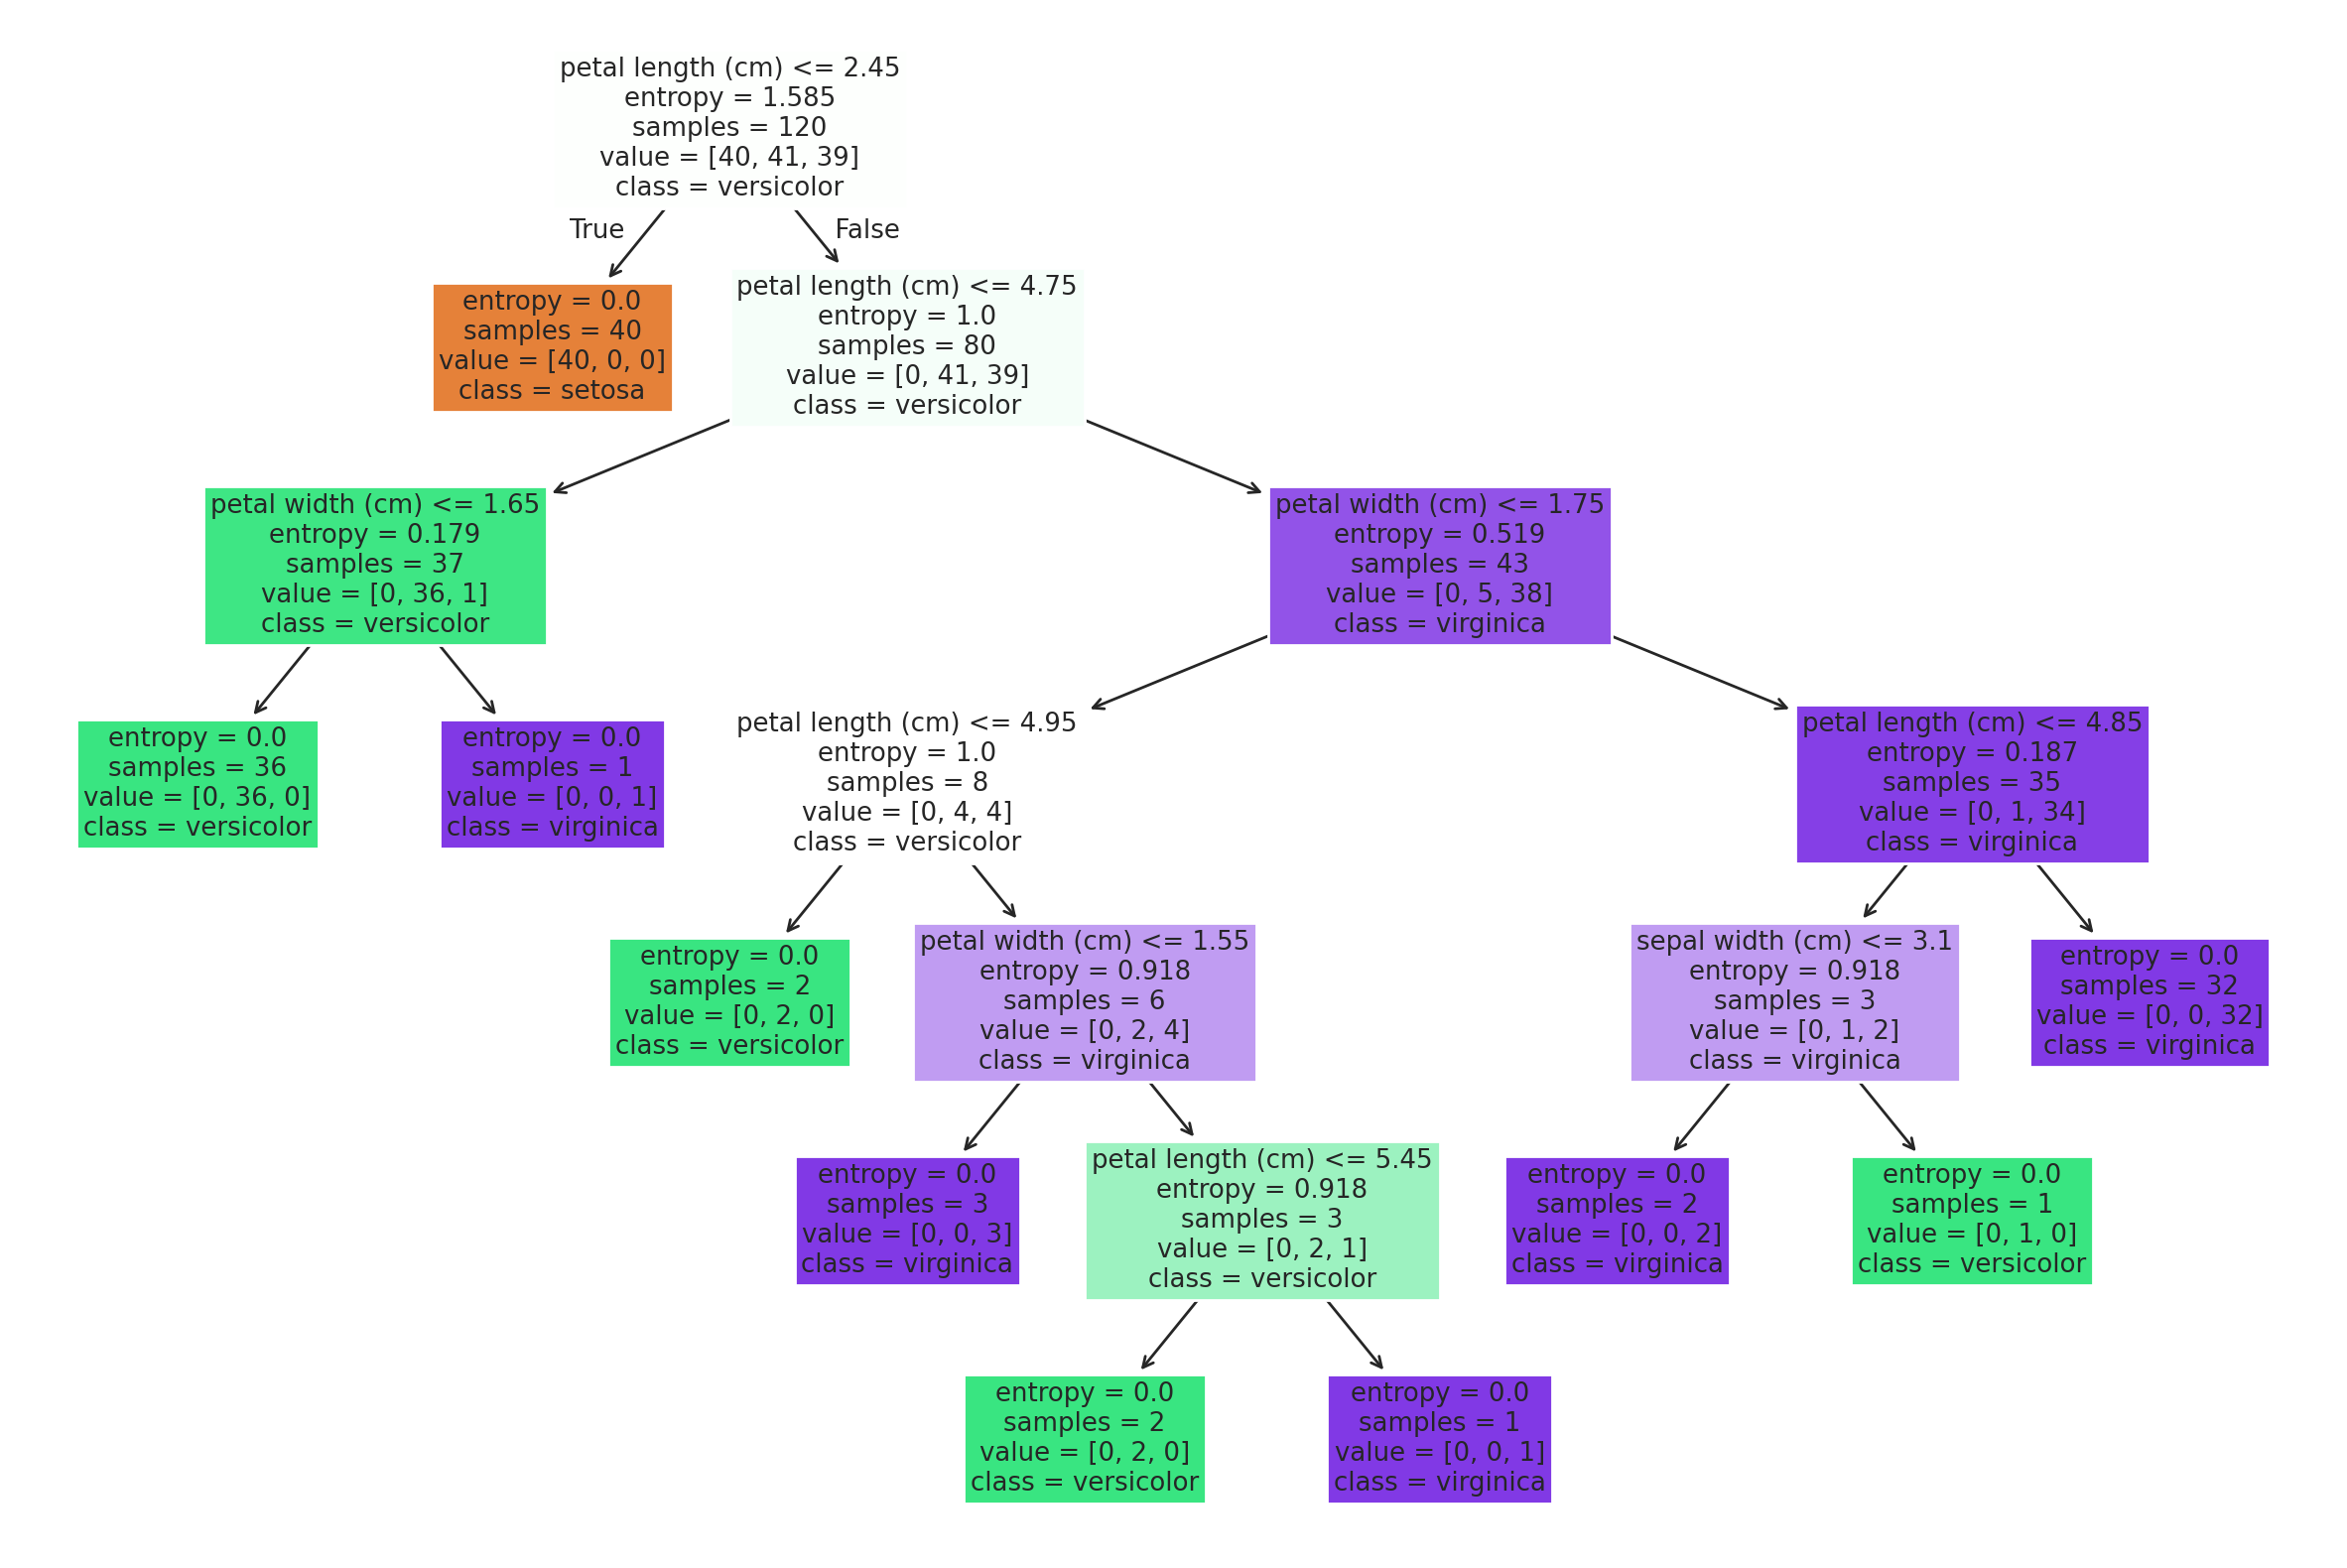

In [25]:
from sklearn.tree import plot_tree
fig = plt.figure(figsize=(15,10))
_ = plot_tree(dtc,
                   feature_names=iris.feature_names,
                   class_names=iris.target_names,
                   filled=True)

Note that instead of using information gain like we discussed in class, this example uses the Gini index.  To read more about the difference between Gini, entropy, and information gain check out the last cell of this notebook (optional).  

Also for more a more in depth article on decision trees check out [this](https://medium.com/analytics-vidhya/decision-tree-in-python-a667af9943eb) one.

### OPTIONAL

Additional information from this [article](https://medium.com/@chandradip93/difference-between-information-gain-entropy-and-gini-index-and-when-to-use-them-6bd0d10ed4ec)

Information gain, entropy, and Gini index are commonly used metrics in decision tree algorithms to determine the best split when building a tree.

Entropy is a measure of the impurity or uncertainty of a set of data. It ranges from 0 (completely pure) to 1 (completely impure). When building a decision tree, the entropy of a set is calculated before and after a split, and the change in entropy is used to determine the information gain.

Information gain is a measure of the difference in entropy between the set before and after a split. The attribute that provides the highest information gain is chosen as the split attribute.

Gini index is another measure of impurity or uncertainty. It ranges from 0 (completely pure) to 1 (completely impure). The Gini index measures the probability of a random sample being incorrectly labeled when it is randomly labeled according to the distribution of the labels in the set. When building a decision tree, the Gini index of a set is calculated before and after a split, and the change in Gini index is used to determine the split attribute.

In general, all three metrics can be used in decision tree algorithms to determine the best split attribute. However, some situations may favor one metric over the others. For example, when dealing with binary classification problems, Gini index is preferred over entropy because it tends to be more computationally efficient. On the other hand, entropy is preferred when the data set is imbalanced, meaning there is a significant difference in the number of instances belonging to different classes. Information gain is a popular metric that is often used because it is easy to understand and generally works well in a variety of situations.

Information gain and entropy are commonly used in decision tree algorithms to select the best attribute to split the data on.
To understand when to use information gain and entropy, consider the following example: Suppose you want to build a decision tree to predict whether a person will purchase a product based on their demographic and behavioral characteristics. You have a dataset that contains the following attributes: age, gender, income, education level, previous purchases, and online behavior.

To build the decision tree, you need to select the best attribute to split the data on at each node of the tree. Information gain and entropy can be used to measure the quality of each split.

For example, suppose you want to split the data based on the attribute “previous purchases”. You can calculate the entropy of the data set before and after the split. If the entropy decreases significantly after the split, it means that the split is informative and can help you make better predictions.

Let’s say the entropy of the data set before the split is 0.8. After splitting the data on “previous purchases”, the entropy of the two resulting subsets are 0.6 and 0.5, respectively. The information gain of this split would be calculated as:

Information Gain = Entropy before split — Weighted average entropy after split = 0.8 — ((3/6) * 0.6 + (3/6) * 0.5) = 0.133

This information gain indicates that the split on “previous purchases” is informative and can help you make better predictions.

Similarly, you can use information gain and entropy to evaluate the quality of other attribute splits and select the best one to build the decision tree.